<a href="https://colab.research.google.com/github/imchrisrueda/extML/blob/main/k_brazos/banditUCB.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Bandido de k-brazos — Comparación de mejores configuraciones (ε-greedy vs Softmax vs UCB)

Descripción: En este notebook se comparan, sobre la misma instancia del bandido de k-brazos, las mejores configuraciones identificadas previamente para tres enfoques de exploración/explotación: ε-greedy, Softmax (Boltzmann) y UCB (UCB1/UCB2). El objetivo es contrastar su desempeño usando métricas complementarias: recompensa promedio, porcentaje de selección del brazo óptimo y regret acumulado.

## Algoritmos y configuraciones comparadas

Se incluyen únicamente las configuraciones “ganadoras” dentro de cada enfoque (según los notebooks individuales), evaluadas por separado en cada distribución (Normal, Bernoulli y Binomial).

### ε-greedy
Política:
$\displaystyle \pi(a)=\begin{cases}
\arg\max_a Q(a) & \text{con prob. } 1-\varepsilon\\
\text{acción aleatoria} & \text{con prob. } \varepsilon
\end{cases}$

Configuraciones usadas:
- Normal: $\varepsilon = 0.1$
- Bernoulli: $\varepsilon = 0.0$
- Binomial: $\varepsilon = 0.1$

### Softmax (Boltzmann)
Política:
$\displaystyle \pi(a)=\frac{\exp\left(Q(a)/T\right)}{\sum_b \exp\left(Q(b)/T\right)}$

Configuraciones usadas:
- Normal: $T = 1.0$
- Bernoulli: $T = 0.1$
- Binomial: $T = 1.0$

### UCB
Se utiliza la mejor configuración UCB identificada en el notebook de UCB para cada distribución (UCB1/UCB2 según corresponda).

UCB1:
$\displaystyle \mathrm{UCB}(a)=Q(a)+c\sqrt{\frac{\ln t}{N(a)}}$

UCB2:
$\displaystyle \mathrm{UCB2}(a)=Q(a)+a_{n,r_a},\quad
a_{n,r}=\sqrt{\frac{(1+\alpha)\,\ln\!\left(\frac{e\,n}{\tau(r)}\right)}{2\,\tau(r)}},\quad
\tau(r)=\left\lceil(1+\alpha)^r\right\rceil$

Configuraciones usadas:
- Normal: UCB2 con $\alpha = 0.9$
- Bernoulli: UCB2 con $\alpha = 0.1$
- Binomial: UCB2 con $\alpha = 0.1$

## Preparación del entorno

In [1]:
# Copiar el repositorio.

# En Google Colab (ejemplo):
# !git clone https://github.com/imchrisrueda/extML.git
# %cd /content/extML/k_brazos


In [1]:
# Importamos todas las clases y funciones

import sys, os
sys.path.insert(0, os.path.abspath(".."))
from pathlib import Path
from typing import List
from k_brazos.src.plotting.plotting import get_algorithm_label

import numpy as np

# Añadir directorios al path de Python 
sys.path.append('/content/eml_k_bandit')
sys.path.append('/content/eml_k_bandit/k_brazos')

cwd = Path.cwd()
for candidate in (cwd, cwd / 'k_brazos'):
    candidate_str = str(candidate)
    if candidate_str not in sys.path and candidate.exists():
        sys.path.append(candidate_str)

# Clases y funciones necesarias para el proyecto
from src.algorithms import Algorithm, UCB1, UCB2, EpsilonGreedy, Softmax
from src.arms import ArmNormal, ArmBinomial, ArmBernoulli, Bandit
from src.plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret


## Experimento

La función `run_experiment(...)` implementa el bucle principal de simulación para una instancia de bandido y un conjunto de algoritmos. En cada ejecución (`run`) se reinicia el estado de los algoritmos, se simulan `steps` interacciones y se acumulan las métricas relevantes.

Para asegurar reproducibilidad, se fija una semilla (por ejemplo con `np.random.seed(...)`) antes de ejecutar los experimentos.

En este notebook, `run_experiment(...)` se utiliza para comparar las mejores configuraciones seleccionadas previamente de tres enfoques: ε-greedy, Softmax y UCB, evaluadas sobre tres distribuciones de recompensa: Normal, Bernoulli y Binomial.

Las salidas del experimento son:

- `rewards`: recompensa promedio por paso y algoritmo.
- `optimal_selections`: proporción de veces que se selecciona el brazo óptimo en cada paso.
- `regrets`: regret acumulado empírico por algoritmo.
- `counts_accum` y `values_accum`: estadísticas agregadas por brazo para análisis posteriores.

In [3]:
def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):

    optimal_arm = bandit.optimal_arm  # Necesario para calcular el porcentaje de selecciones óptimas.

    rewards = np.zeros((len(algorithms), steps)) # Matriz para almacenar las recompensas promedio.

    optimal_selections = np.zeros((len(algorithms), steps))  # Matriz para almacenar el porcentaje de selecciones óptimas.

    np.random.seed(seed)  # Fijamos semilla para que las ejecuciones sean reproducibles

    #para el regret
    regrets = np.zeros((len(algorithms), steps)) # Matriz para almacenar el arrepentimiento
    q = bandit.get_expected_value(optimal_arm) # Recompensa del brazo óptimo
    # Lo voy acumulando para mostrarlo en el gráfico
    counts_accum = np.zeros((len(algorithms), bandit.k))
    values_accum = np.zeros((len(algorithms), bandit.k))


    for run in range(runs):
        current_bandit = Bandit(arms=bandit.arms)

        for algo in algorithms:
            algo.reset() # En cada corrida reiniciamos los algoritmos para no mezclar experiencia entre runs.

        total_regret = np.zeros(len(algorithms)) # Acumulador de arrepentimiento por algoritmo

        for step in range(steps):
            for idx, algo in enumerate(algorithms):
                chosen_arm = algo.select_arm() # Seleccionar un brazo según la política del algoritmo.
                reward = current_bandit.pull_arm(chosen_arm) # Obtener la recompensa del brazo seleccionado.
                algo.update(chosen_arm, reward) # Actualizar el valor estimado del brazo seleccionado.

                rewards[idx, step] += reward # Acumular la recompensa obtenida en la matriz rewards para el algoritmo idx en el paso step.
                
                #modificar optimal_selections cuando el brazo elegido se corresponda con el brazo óptimo optimal_arm
                if chosen_arm == optimal_arm: # Si se ha elegido el brazo óptimo...
                    optimal_selections[idx, step] += 1 # ... añadir uno a la acumulación de selecciones de brazos óptimos


                total_regret[idx] += (q - reward) # El arrepentimiento es la q - la recompensa  -> lo que hubiéramos obtenido eligiendo el mejor brazo
                regrets[idx, step] += total_regret[idx] # Actualizar el regret acumulado


        for idx, algo in enumerate(algorithms):
            counts_accum[idx] += algo.counts
            values_accum[idx] += algo.values
            
    #calcular el porcentaje de selecciones óptimas y almacenar en optimal_selections
    rewards /= runs
    optimal_selections /= runs
    regrets /= runs

    counts_accum /= runs
    values_accum /= runs


    return rewards, optimal_selections, regrets, counts_accum, values_accum


## Ejecución del experimento

Se ejecuta el estudio con los parámetros `k=10`, `steps=1000` y `runs=500`, usando una semilla fija (`seed=42`) para asegurar reproducibilidad. La comparación se realiza sobre tres tipos de bandido:

- Normal ($N(\mu,\sigma^2)$ con $\sigma=1$ en la implementación actual).
- Bernoulli (recompensas binarias 0/1).
- Binomial (`n=10`).

En cada distribución se comparan las mejores configuraciones identificadas previamente para tres enfoques (ε-greedy, Softmax y UCB). Para cada enfoque se utiliza una única configuración por distribución.

### ε-greedy
- Normal: $\varepsilon=0.1$
- Bernoulli: $\varepsilon=0.0$
- Binomial: $\varepsilon=0.1$

### Softmax
- Normal: $T=1.0$
- Bernoulli: $T=0.1$
- Binomial: $T=1.0$

### UCB
- Normal: UCB2 con $\alpha=0.9$
- Bernoulli: UCB2 con $\alpha=0.1$
- Binomial: UCB2 con $\alpha=0.1$

El análisis se centra en comparar, para cada distribución, el desempeño de las tres políticas en términos de recompensa promedio, selección del brazo óptimo y regret acumulado.

In [4]:
# Parámetros del experimento y construcción de algoritmos UCB1 y UCB2

seed = 42
np.random.seed(seed)

k = 10
steps = 1000
runs = 500

def build_best_algorithms(k: int, dist: str):
    # Devuelve [ε-greedy, Softmax, UCB] para la distribución dada
    if dist == "normal":
        return [
            EpsilonGreedy(k=k, epsilon=0.1),
            Softmax(k=k, temperature=1.0),
            UCB2(k=k, alpha=0.9),
        ]
    if dist == "bernoulli":
        return [
            EpsilonGreedy(k=k, epsilon=0.0),
            Softmax(k=k, temperature=0.1),
            UCB2(k=k, alpha=0.1),
        ]
    if dist == "binomial":
        return [
            EpsilonGreedy(k=k, epsilon=0.1),
            Softmax(k=k, temperature=1.0),
            UCB2(k=k, alpha=0.1),
        ]
    raise ValueError("dist debe ser: 'normal', 'bernoulli' o 'binomial'")


In [5]:
# Crear bandidos (Normal, Bernoulli, Binomial) y ejecutar experimentos
bandit_normal = Bandit(arms=ArmNormal.generate_arms(k))
bandit_bernoulli = Bandit(arms=ArmBernoulli.generate_arms(k))
bandit_binomial = Bandit(arms=ArmBinomial.generate_arms(k, n=10))

algorithms_normal = build_best_algorithms(k, "normal")
algorithms_bernoulli = build_best_algorithms(k, "bernoulli")
algorithms_binomial = build_best_algorithms(k, "binomial")

rewards_normal, optimal_normal, regrets_normal, counts_normal, values_normal = run_experiment(
    bandit_normal, algorithms_normal, steps, runs
)
rewards_bernoulli, optimal_bernoulli, regrets_bernoulli, counts_bernoulli, values_bernoulli = run_experiment(
    bandit_bernoulli, algorithms_bernoulli, steps, runs
)
rewards_binomial, optimal_binomial, regrets_binomial, counts_binomial, values_binomial = run_experiment(
    bandit_binomial, algorithms_binomial, steps, runs
)

In [6]:
# Verificar shapes para las 3 distribuciones (si ya están calculadas)

def print_shapes(name, rewards, optimal, regrets, counts, values):
    print(f"\n=== {name} ===")
    print("rewards:", rewards.shape)
    print("optimal:", optimal.shape)
    print("regrets:", regrets.shape)
    print("counts:", counts.shape)
    print("values:", values.shape)

print_shapes("Normal", rewards_normal, optimal_normal, regrets_normal, counts_normal, values_normal)
print_shapes("Bernoulli", rewards_bernoulli, optimal_bernoulli, regrets_bernoulli, counts_bernoulli, values_bernoulli)
print_shapes("Binomial", rewards_binomial, optimal_binomial, regrets_binomial, counts_binomial, values_binomial)


=== Normal ===
rewards: (3, 1000)
optimal: (3, 1000)
regrets: (3, 1000)
counts: (3, 10)
values: (3, 10)

=== Bernoulli ===
rewards: (3, 1000)
optimal: (3, 1000)
regrets: (3, 1000)
counts: (3, 10)
values: (3, 10)

=== Binomial ===
rewards: (3, 1000)
optimal: (3, 1000)
regrets: (3, 1000)
counts: (3, 10)
values: (3, 10)


## Visualización de los resultados

En esta sección se presentan las gráficas utilizadas para analizar el comportamiento del algoritmo **UCB** en el problema de **k-brazos** (para las distribuciones Bernoulli, Binomial y Normal). 


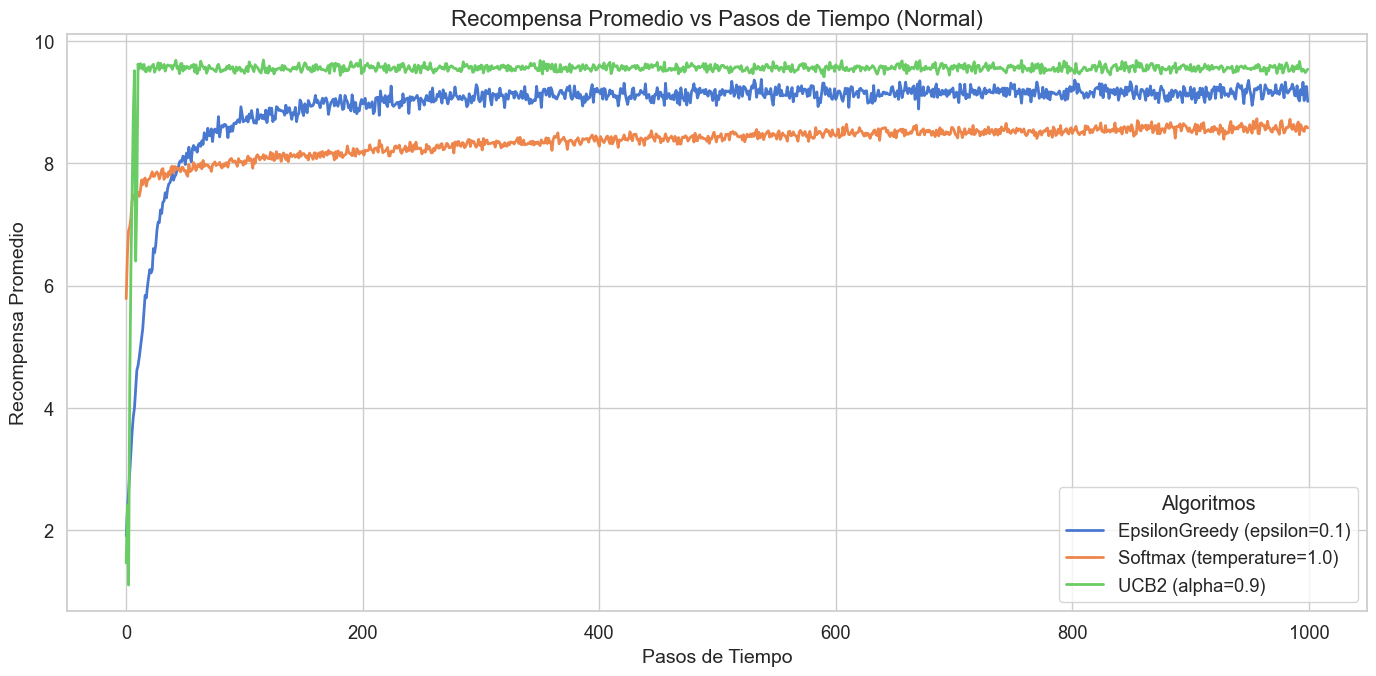

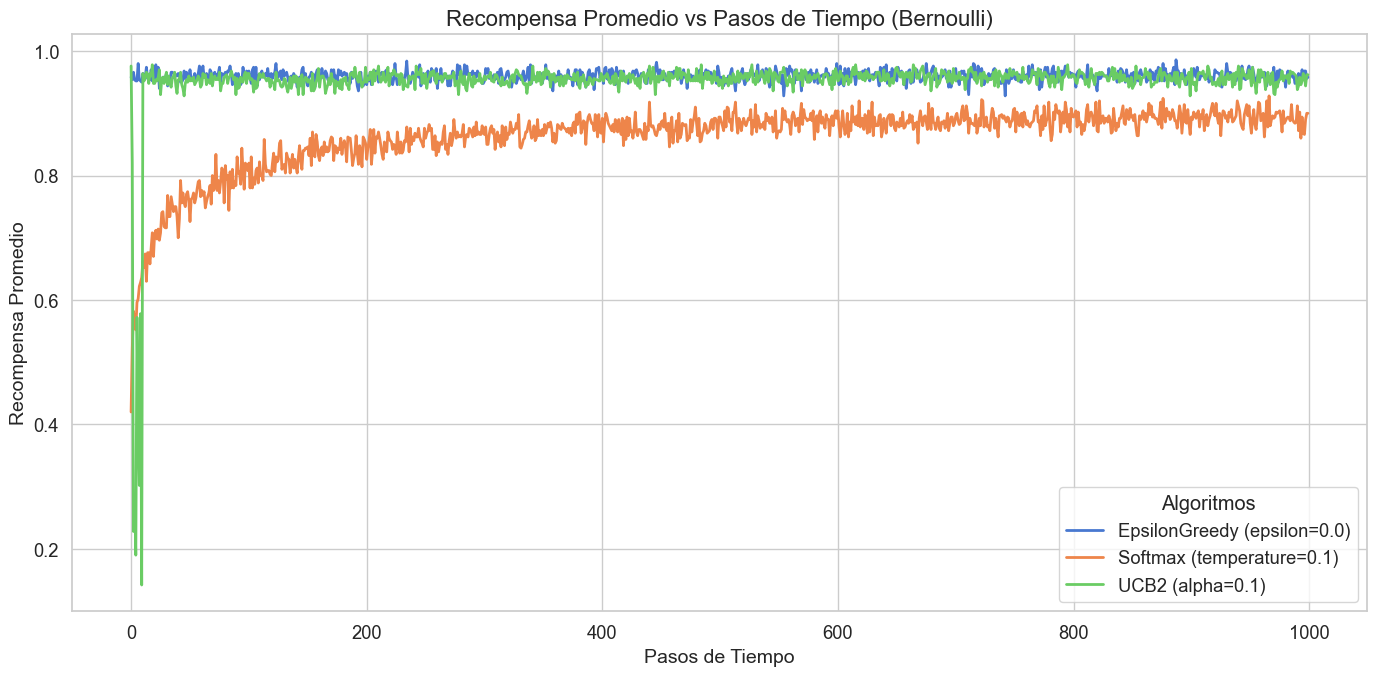

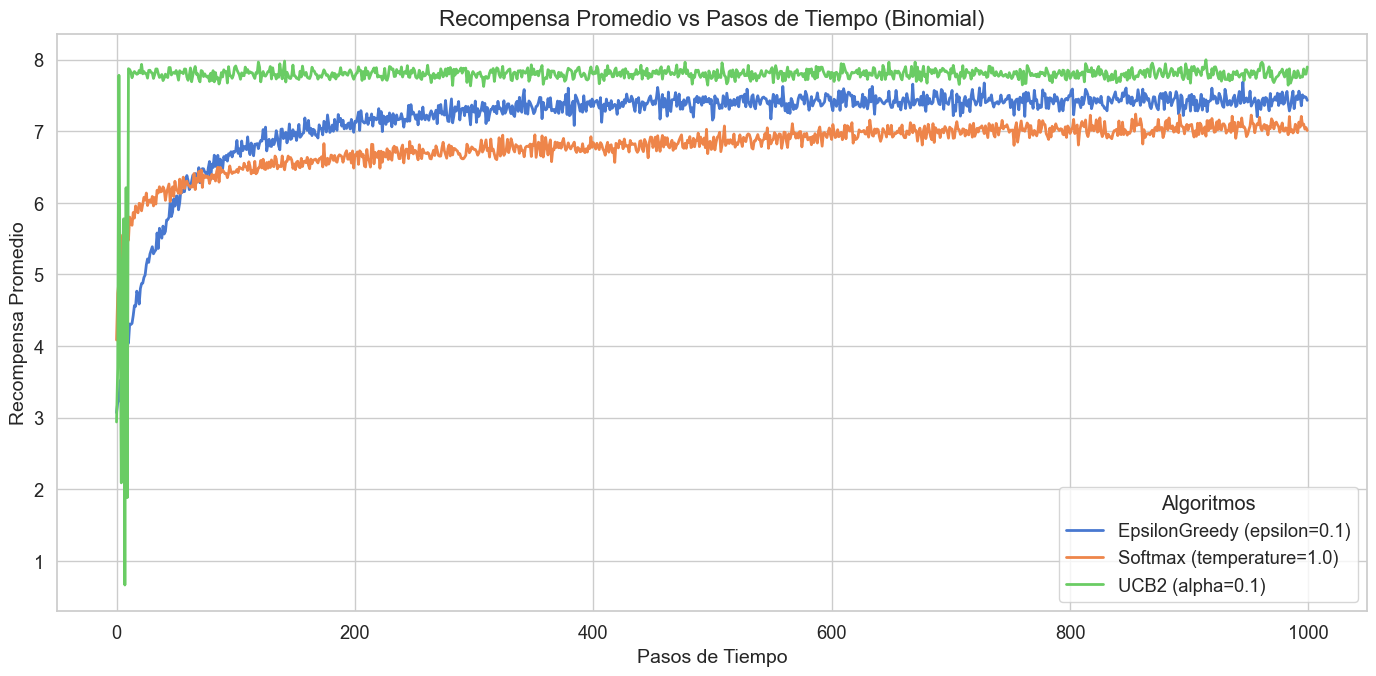

In [7]:
# Graficar recompensas promedio
plot_average_rewards(steps, rewards_normal, algorithms_normal, 'Normal')
plot_average_rewards(steps, rewards_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_average_rewards(steps, rewards_binomial, algorithms_binomial, 'Binomial')

In [8]:

def running_mean_curve(rewards_per_step: np.ndarray) -> np.ndarray:
    # rewards_per_step: (steps,)
    return np.cumsum(rewards_per_step) / (np.arange(len(rewards_per_step)) + 1)

def last100_mean_from_rewards_matrix(rewards_matrix: np.ndarray, last_n: int = 100) -> np.ndarray:
    # rewards_matrix: (n_algos, steps)
    out = np.zeros(rewards_matrix.shape[0], dtype=float)
    for i in range(rewards_matrix.shape[0]):
        curve = running_mean_curve(rewards_matrix[i])
        out[i] = curve[-last_n:].mean()
    return out

def print_last100_table_ucb():
    labels_normal = [get_algorithm_label(a) for a in algorithms_normal]
    labels_bern   = [get_algorithm_label(a) for a in algorithms_bernoulli]
    labels_binom  = [get_algorithm_label(a) for a in algorithms_binomial]

    vals_normal = last100_mean_from_rewards_matrix(rewards_normal, 100)
    vals_bern   = last100_mean_from_rewards_matrix(rewards_bernoulli, 100)
    vals_binom  = last100_mean_from_rewards_matrix(rewards_binomial, 100)

    # asumimos mismos labels/orden en las 3 distribuciones
    labels = labels_normal

    print("| Distribución | " + " | ".join(labels) + " |")
    print("|---|" + "|".join(["---:"] * len(labels)) + "|")
    print("| Normal | "    + " | ".join([f"{v:.3f}" for v in vals_normal]) + " |")
    print("| Bernoulli | " + " | ".join([f"{v:.3f}" for v in vals_bern])   + " |")
    print("| Binomial | "  + " | ".join([f"{v:.3f}" for v in vals_binom])  + " |")

print_last100_table_ucb()

| Distribución | EpsilonGreedy | Softmax | UCB2 |
|---|---:|---:|---:|
| Normal | 8.913 | 8.342 | 9.514 |
| Bernoulli | 0.960 | 0.861 | 0.951 |
| Binomial | 7.151 | 6.776 | 7.763 |


## Recompensa promedio (comparación de políticas)

En esta sección se compara la **recompensa promedio** obtenida por tres **políticas** (ε-greedy, Softmax y UCB2) usando, en cada distribución, la **mejor configuración** identificada previamente. Las curvas *Recompensa Promedio vs Pasos de Tiempo* muestran el rendimiento medio a lo largo del horizonte (1000 pasos). Para resumir el desempeño final se reporta el **promedio de la recompensa en los últimos 100 pasos** (t=901..1000).

### Resumen cuantitativo (promedio últimos 100 pasos)

| Distribución | ε-greedy | Softmax | UCB2 |
|---|---:|---:|---:|
| Normal | 8.913 | 8.342 | **9.514** |
| Bernoulli | **0.960** | 0.861 | 0.951 |
| Binomial | 7.151 | 6.776 | **7.763** |

### Comentario por distribución

**Normal**
- Se observa una **convergencia rápida** en los tres casos, pero **UCB2** estabiliza en el nivel más alto (9.514). Esto es consistente con lo visto antes: en Normal el óptimo se distingue relativamente pronto y UCB2 logra explotar esa ventaja con menos “costo” sostenido.
- **ε-greedy** (ε=0.1) queda segundo (8.913): explora de forma constante y eso introduce un “techo” en la recompensa promedio final.
- **Softmax** (T=1.0) queda por debajo (8.342), lo que sugiere una exploración más dispersa (o menos agresiva en la explotación) frente a esta instancia.

**Bernoulli**
- Aquí el mejor desempeño final es **ε-greedy** (ε=0.0) con 0.960, ligeramente por encima de **UCB2** (0.951). Esto indica que, en esta instancia, una política más “greedy” tuvo la suerte de **engancharse temprano** con el brazo correcto y mantenerlo.
- **UCB2** (α=0.1) sigue muy cerca, coherente con su buen rendimiento previo en Bernoulli (épocas cortas → corrección frecuente).
- **Softmax** (T=0.1) queda más abajo (0.861), consistente con que mantiene selecciones no óptimas durante más tiempo en un entorno 0/1 con diferencias pequeñas entre brazos.

**Binomial**
- **UCB2** vuelve a ser el mejor (7.763), con **ε-greedy** segundo (7.151) y **Softmax** tercero (6.776). El patrón coincide con lo observado antes: cuando el brazo óptimo queda bien separado, UCB2 tiende a concentrar selecciones de forma eficiente.
- La brecha entre ε-greedy y Softmax sugiere que, con estos hiperparámetros “ganadores”, Softmax aún retiene más exploración residual que ε-greedy en el tramo final.

**Nota:** las magnitudes absolutas de recompensa no se comparan entre distribuciones debido a sus distintas escalas; la comparación relevante es **entre políticas dentro de cada distribución**.

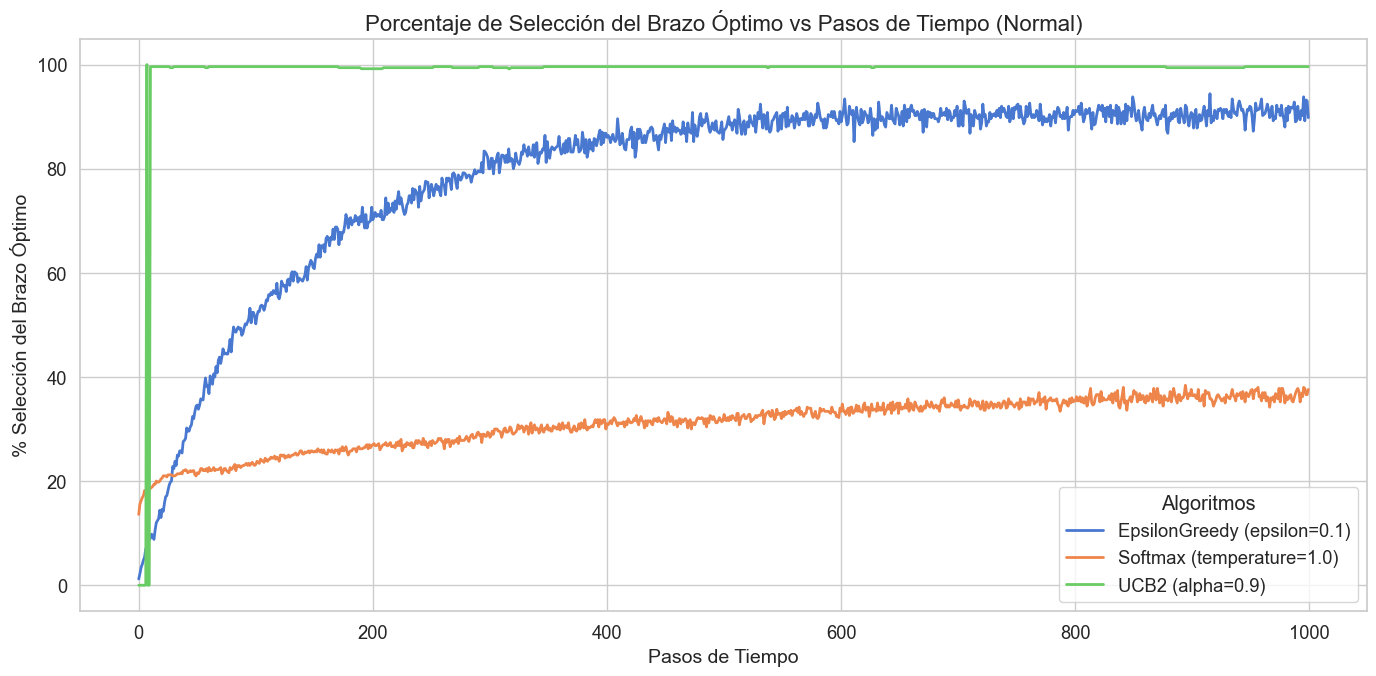

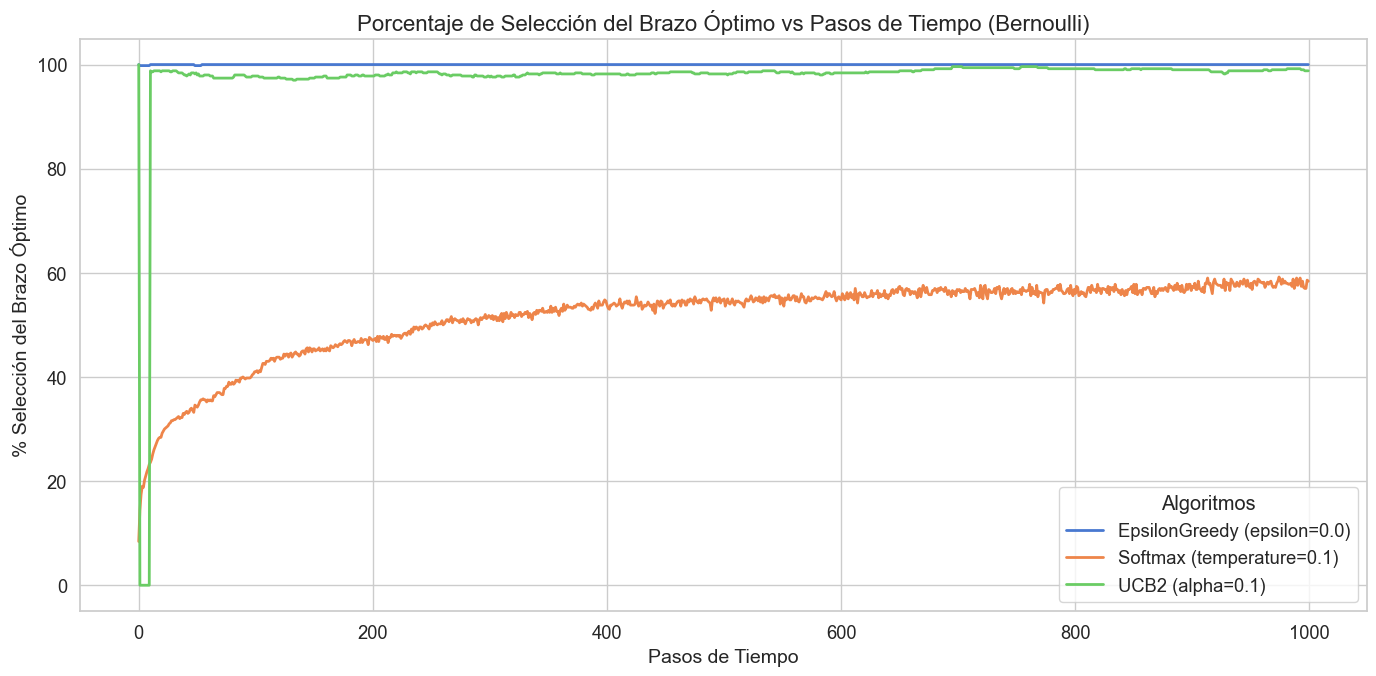

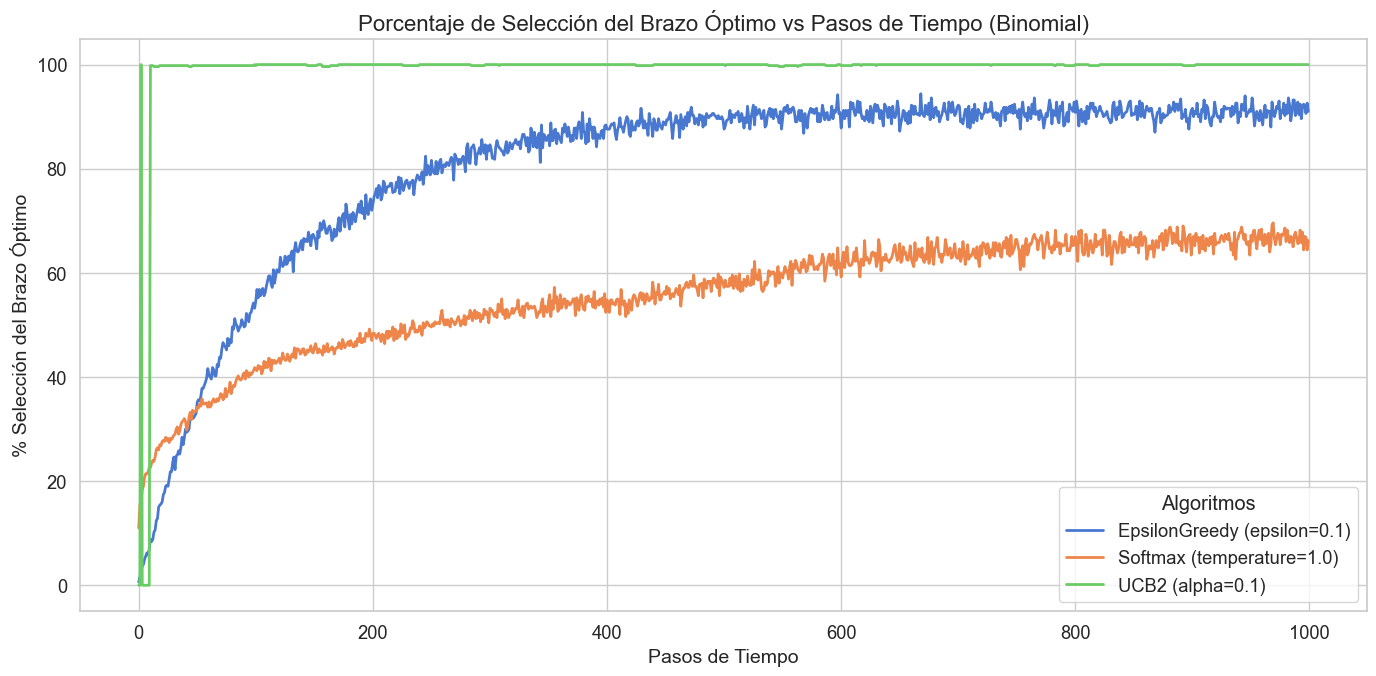

In [9]:
# Graficar porcentaje de selección del brazo óptimo

plot_optimal_selections(steps, optimal_normal, algorithms_normal, 'Normal')
plot_optimal_selections(steps, optimal_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_optimal_selections(steps, optimal_binomial, algorithms_binomial, 'Binomial')


In [10]:
def label_ucb(algo):
    name = type(algo).__name__
    if hasattr(algo, "c"):
        return f"{name} (c={algo.c})"
    if hasattr(algo, "alpha"):
        return f"{name} (α={algo.alpha})"
    return name

def final_optimal_pct(optimal_matrix: np.ndarray) -> np.ndarray:
    # optimal_matrix: (n_algos, steps), valores en [0,1]
    return optimal_matrix[:, -1] * 100.0

labels = [label_ucb(a) for a in algorithms_normal]  # mismo orden que en optimal_normal

v_norm = final_optimal_pct(optimal_normal)
v_bern = final_optimal_pct(optimal_bernoulli)
v_bin  = final_optimal_pct(optimal_binomial)

print("| Distribución | " + " | ".join(labels) + " |")
print("|---|" + "|".join(["---:"] * len(labels)) + "|")
print("| Normal | "    + " | ".join([f"{v:.1f}%" for v in v_norm]) + " |")
print("| Bernoulli | " + " | ".join([f"{v:.1f}%" for v in v_bern]) + " |")
print("| Binomial | "  + " | ".join([f"{v:.1f}%" for v in v_bin])  + " |")

| Distribución | EpsilonGreedy | Softmax | UCB2 (α=0.9) |
|---|---:|---:|---:|
| Normal | 89.8% | 37.6% | 99.6% |
| Bernoulli | 100.0% | 58.4% | 98.8% |
| Binomial | 91.0% | 66.2% | 100.0% |


## Porcentaje de selección del brazo óptimo

Esta métrica mide, en cada paso, el porcentaje de corridas en las que se eligió el brazo óptimo. Es útil porque **no depende de la escala de recompensas** y permite ver cuán rápido cada política identifica y explota el óptimo.

| Distribución | EpsilonGreedy | Softmax | UCB2 |
|---|---:|---:|---:|
| Normal | 89.8% | 37.6% | **99.6%** |
| Bernoulli | **100.0%** | 58.4% | 98.8% |
| Binomial | 91.0% | 66.2% | **100.0%** |

### Lectura por distribución

**Normal**
- **UCB2** alcanza prácticamente selección óptima perfecta (**99.6%**), coherente con lo observado antes: en Normal, UCB2 se comporta como una política muy eficiente para identificar y explotar el mejor brazo.
- **ε-greedy (ε=0.1)** sube de forma gradual y se estabiliza alrededor de ~90%: con ε fijo, siempre se “pierde” una fracción de pasos en exploración aleatoria.
- **Softmax (T=1.0)** queda muy bajo (37.6%): en esta instancia, esa temperatura mantiene demasiada dispersión entre brazos durante gran parte del horizonte.

**Bernoulli**
- **ε-greedy (ε=0.0)** llega a **100%**: esto indica que, en esta instancia concreta, el algoritmo “engancha” el brazo óptimo muy temprano y luego no lo suelta (no hay exploración).
- **UCB2 (α=0.1)** también es muy alto (98.8%), pero no llega a 100% porque conserva exploración (aunque controlada).
- **Softmax (T=0.1)** se queda en 58.4%: aun con temperatura baja, su exploración estocástica reparte probabilidad en brazos no óptimos durante demasiado tiempo.

**Binomial**
- **UCB2 (α=0.1)** alcanza **100%**, consistente con un bandido “fácil” donde el óptimo se distingue rápido.
- **ε-greedy (ε=0.1)** converge cerca de 91% por el mismo motivo que en Normal: la exploración aleatoria permanente evita que llegue a 100%.
- **Softmax (T=1.0)** mejora respecto a Normal (66.2%), pero sigue lejos del óptimo: la temperatura seleccionada aún induce una exploración relativamente alta.

### Consistencia con resultados anteriores

En general, este comportamiento es consistente con lo que veníamos viendo:

- **UCB2** domina en **Normal** y **Binomial**, alcanzando (casi) 100% de selección óptima, como ya sugerían sus mejores curvas de recompensa y su estabilidad en esas distribuciones.
- En **Bernoulli**, donde el problema suele ser más sensible, aparece el caso particular donde **ε=0.0** funciona excepcionalmente bien porque el óptimo se identifica temprano; esto ya lo habíamos comentado como una posibilidad en instancias favorables.
- **Softmax** queda por debajo en las tres distribuciones porque, incluso con la mejor temperatura elegida previamente, mantiene más dispersión de selección que ε-greedy/UCB2 en esta instancia.

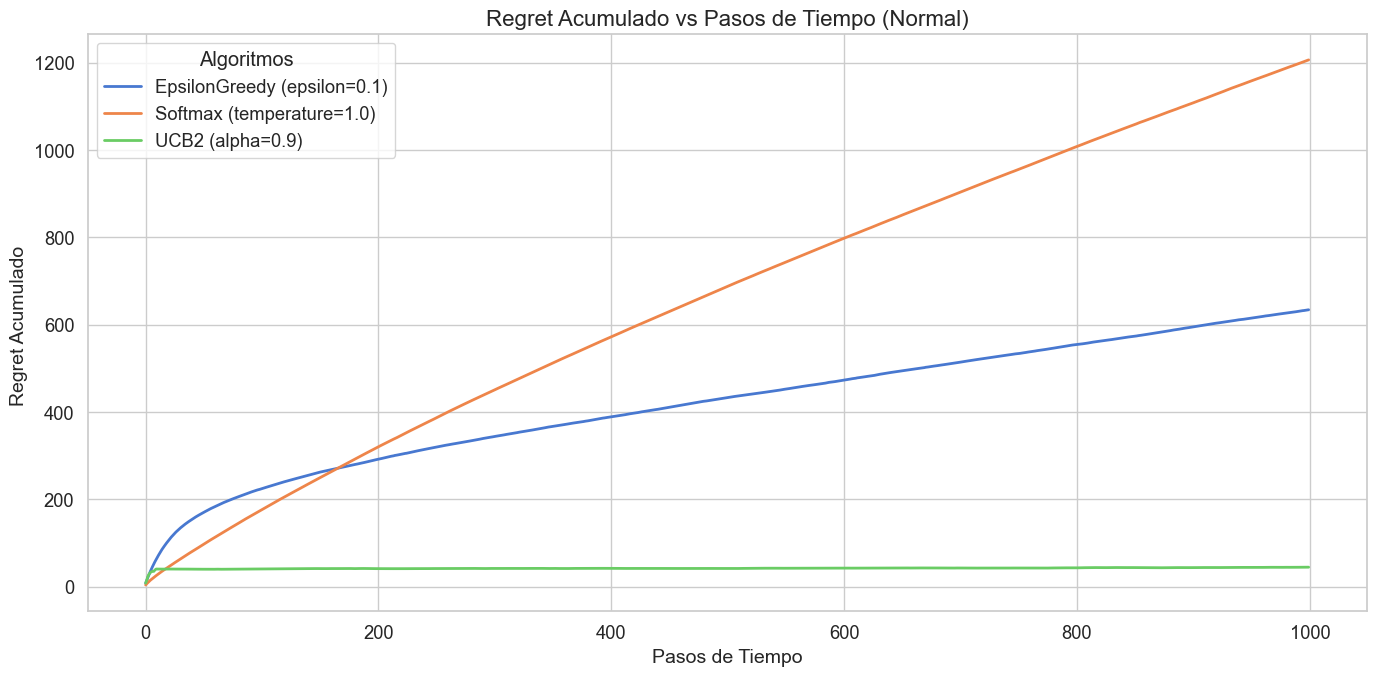

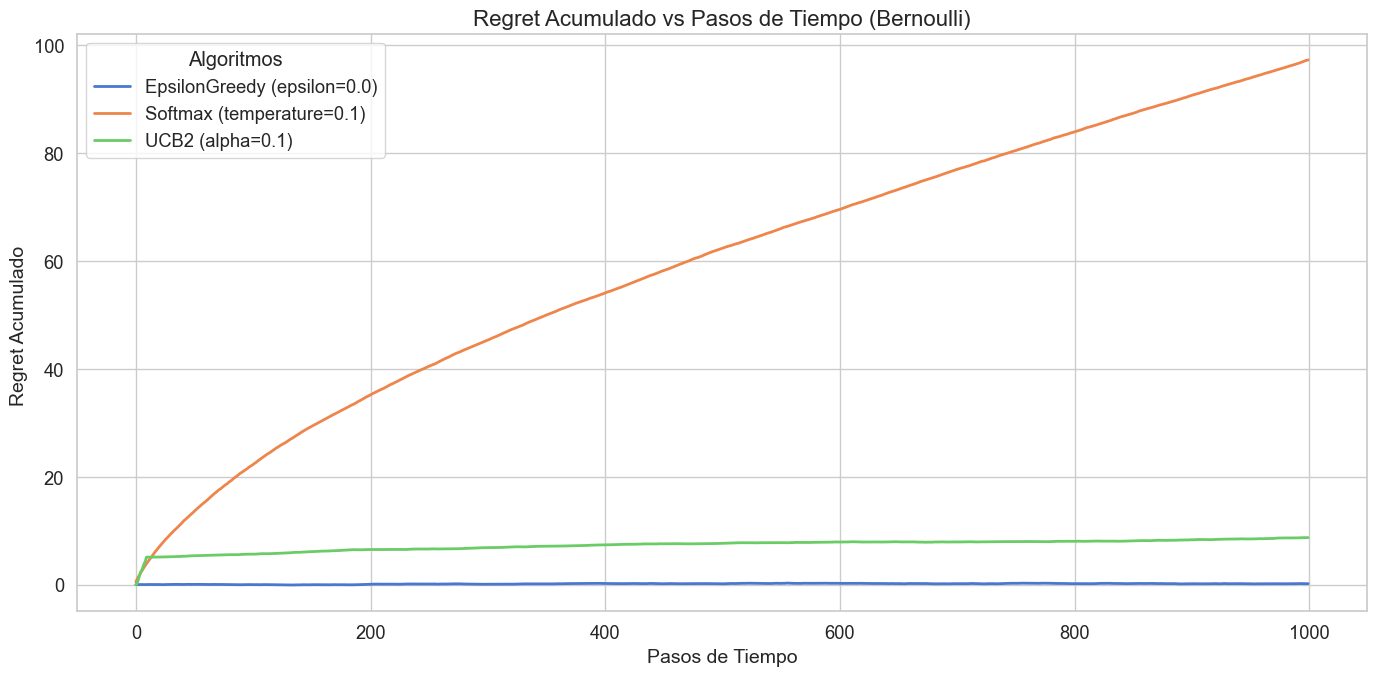

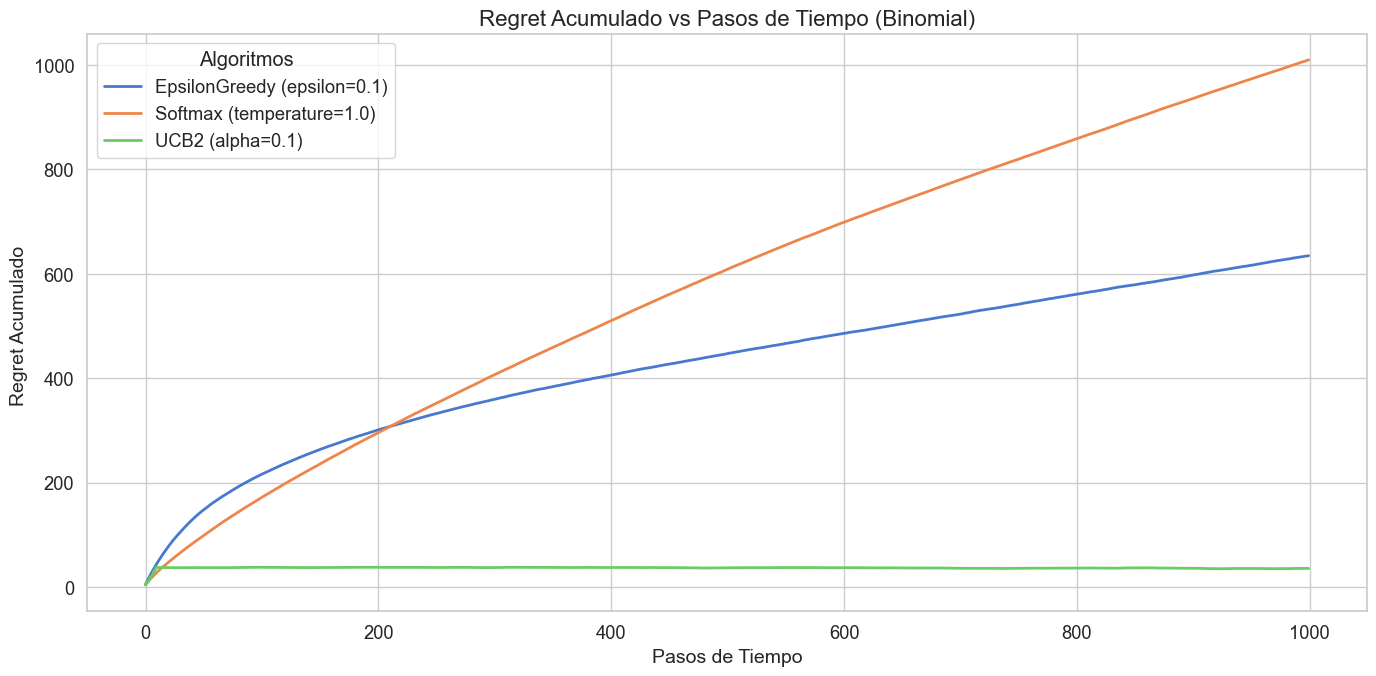

In [11]:
# Graficar regret acumulado

plot_regret(steps, regrets_normal, algorithms_normal, 'Normal')
plot_regret(steps, regrets_bernoulli, algorithms_bernoulli, 'Bernoulli')
plot_regret(steps, regrets_binomial, algorithms_binomial, 'Binomial')


In [12]:
def final_regret(regret_matrix: np.ndarray) -> np.ndarray:
    # regret_matrix: (n_algos, steps)
    return regret_matrix[:, -1]

labels = [label_ucb(a) for a in algorithms_normal]

r_norm = final_regret(regrets_normal)
r_bern = final_regret(regrets_bernoulli)
r_bin  = final_regret(regrets_binomial)

print("| Distribución | " + " | ".join(labels) + " |")
print("|---|" + "|".join(["---:"] * len(labels)) + "|")
print("| Normal | "    + " | ".join([f"{v:.2f}" for v in r_norm]) + " |")
print("| Bernoulli | " + " | ".join([f"{v:.2f}" for v in r_bern]) + " |")
print("| Binomial | "  + " | ".join([f"{v:.2f}" for v in r_bin])  + " |")

| Distribución | EpsilonGreedy | Softmax | UCB2 (α=0.9) |
|---|---:|---:|---:|
| Normal | 634.09 | 1206.37 | 44.58 |
| Bernoulli | 0.18 | 97.31 | 8.72 |
| Binomial | 634.63 | 1009.93 | 35.41 |


### Regret acumulado (comparación de **políticas**)

El regret acumulado usado aquí es empírico: en cada paso se acumula `q* − r_t`, donde `q*` es el valor esperado del brazo óptimo y `r_t` la recompensa observada. **Menor regret** implica **menor pérdida acumulada** por no elegir el óptimo.

#### Regret final en t=1000 (menor es mejor)

| Distribución | EpsilonGreedy | Softmax | UCB2 |
|---|---:|---:|---:|
| Normal | 634.09 | 1206.37 | 44.58 |
| Bernoulli | 0.18 | 97.31 | 8.72 |
| Binomial | 634.63 | 1009.93 | 35.41 |

#### Lectura por distribución

**Normal**
- **UCB2 (α=0.9)** obtiene un regret extremadamente bajo (`44.58`), coherente con su selección óptima ≈ `99.6%` y su mayor recompensa promedio.
- **ε-greedy (ε=0.1)** acumula regret alto (`634.09`): aunque converge bien, la exploración constante sigue “pagándose” durante todo el horizonte.
- **Softmax (T=1.0)** es el peor (`1206.37`), consistente con su baja concentración en el brazo óptimo.

**Bernoulli**
- **ε-greedy (ε=0.0)** logra regret casi nulo (`0.18`), coherente con el `100%` de selección óptima al final: en esta instancia, “acierta” temprano y no vuelve a desviarse.
- **UCB2 (α=0.1)** también mantiene regret bajo (`8.72`), consistente con ≈ `98.8%` de selección óptima.
- **Softmax (T=0.1)** vuelve a mostrar el peor desempeño (`97.31`), lo cual cuadra con su dispersión residual (≈ `58.4%` en el óptimo).

**Binomial**
- **UCB2 (α=0.1)** vuelve a dominar (`35.41`) y llega a `100%` de selección óptima al final, lo que explica el regret tan bajo.
- **ε-greedy (ε=0.1)** queda alto (`634.63`) por la exploración persistente.
- **Softmax (T=1.0)** es el peor (`1009.93`), coherente con que no concentra suficiente probabilidad en el óptimo.

> Nota: el regret (y su magnitud) **no se compara entre distribuciones** porque depende de `q*` y de la escala de recompensas; la comparación relevante es **entre políticas dentro de cada distribución**.

## Conclusiones (comparación de políticas: ε-greedy vs Softmax vs UCB)

En este notebook se compararon **tres políticas** para el problema del **bandido de k-brazos** sobre tres distribuciones de recompensas (**Normal**, **Bernoulli** y **Binomial**). Para cada distribución se utilizó **la mejor configuración identificada previamente** dentro de cada enfoque:

- **ε-greedy:** Normal (ε=0.1), Bernoulli (ε=0.0), Binomial (ε=0.1)  
- **Softmax:** Normal (T=1.0), Bernoulli (T=0.1), Binomial (T=1.0)  
- **UCB:** Normal (UCB2, α=0.9), Bernoulli (UCB2, α=0.1), Binomial (UCB2, α=0.1)

En esta ejecución (semilla fija), las métricas de **recompensa promedio**, **porcentaje de selección del brazo óptimo** y **regret acumulado** llevaron a conclusiones consistentes dentro de cada distribución.

### Resultados principales por distribución

- **Normal**
  - **UCB2 (α=0.9)** domina con **mayor recompensa promedio** (9.514), **mayor selección del óptimo** (99.6%) y **menor regret** (44.58).
  - **ε-greedy (ε=0.1)** queda en segundo lugar: converge alto (8.913 y 89.8%), pero acumula regret elevado (634.09) por la exploración persistente.
  - **Softmax (T=1.0)** es el peor en esta instancia: baja selección óptima (37.6%) y el mayor regret (1206.37), consistente con una política que mantiene demasiada dispersión.

- **Bernoulli**
  - **ε-greedy (ε=0.0)** obtiene el mejor desempeño global: **recompensa** 0.960, **selección óptima** 100.0% y **regret** casi nulo (0.18). En esta instancia, esto indica que el algoritmo identifica el óptimo muy temprano y luego explota sin desviarse.
  - **UCB2 (α=0.1)** también rinde muy bien (0.951, 98.8%, 8.72), quedando cerca del óptimo pero con una exploración residual que se refleja en regret mayor que ε=0.
  - **Softmax (T=0.1)** queda claramente por debajo (0.861, 58.4%, 97.31), coherente con una concentración insuficiente en el brazo óptimo.

- **Binomial**
  - **UCB2 (α=0.1)** domina nuevamente: **recompensa** 7.763, **selección óptima** 100.0% y **regret** muy bajo (35.41).
  - **ε-greedy (ε=0.1)** converge alto (7.151 y 91.0%), pero paga regret grande (634.63) por exploración continua.
  - **Softmax (T=1.0)** es el peor en esta instancia (6.776, 66.2%, 1009.93), consistente con menor precisión en la identificación/explotación del óptimo.

### Lectura global (consistencia entre métricas)

1. **El ranking por métricas fue coherente dentro de cada distribución.**  
   En general, **mayor selección del brazo óptimo** implicó **mayor recompensa** y **menor regret**. Esto refuerza que las diferencias no son un artefacto de escala, sino cambios reales en el comportamiento de las políticas.

2. **UCB2 fue el ganador en Normal y Binomial; Bernoulli favoreció a ε-greedy (ε=0.0) en esta instancia.**  
   - En **Normal** y **Binomial**, UCB2 logra una **concentración casi total** en el óptimo y por eso reduce drásticamente el regret.  
   - En **Bernoulli**, ε=0 puede ser excelente **si acierta temprano**; en esta ejecución lo hizo, por eso alcanza 100% de selección óptima y regret prácticamente cero.

3. **Softmax fue sistemáticamente inferior en esta comparación.**  
   Incluso usando la mejor temperatura seleccionada previamente, la política Softmax mantuvo una exploración/dispersión mayor, lo cual se reflejó en **menor selección óptima** y **regrets altos** en las tres distribuciones.

### Consideraciones importantes

1. **No existe una política universalmente mejor.**  
   El desempeño depende de la **distribución** y de la **instancia concreta** del bandido. En particular, el caso Bernoulli muestra que políticas muy “explotadoras” (ε=0) pueden rendir extremadamente bien cuando el óptimo se identifica temprano.

2. **Comparar políticas requiere mirar más de una métrica.**  
   La combinación de recompensa promedio, selección del óptimo y regret permite interpretar el resultado de forma robusta: la recompensa explica el nivel alcanzado, la selección óptima explica la precisión, y el regret cuantifica la pérdida acumulada.

3. **Las magnitudes absolutas no se comparan entre distribuciones.**  
   Por escalas distintas (p.ej., Bernoulli en [0,1] vs Normal/Binomial), las comparaciones relevantes son **entre políticas dentro de cada distribución**.

### Limitaciones

- Los resultados dependen de una instancia concreta generada con semilla fija (`seed=42`).
- Sería recomendable repetir con **múltiples semillas** y analizar sensibilidad a hiperparámetros (más valores de ε, T y α), además de variaciones en `k` y parámetros de distribución (por ejemplo `n` en Binomial y `σ` en Normal).
- En particular, el excelente desempeño de **ε=0 en Bernoulli** puede no generalizar si el algoritmo no identifica el óptimo temprano; explorar con más semillas ayudaría a evaluar estabilidad.